In [1]:
from google.colab import drive
import os
import pandas as pd

drive.mount('/content/drive')

base_path = '/content/drive/My Drive/CMPE 255 Data Mining/Dataset'

print(f"Listing contents of '{base_path}':")
if os.path.exists(base_path):
    for item in os.listdir(base_path):
        print(item)
else:
    print(f"Error: The path '{base_path}' does not exist. Please check the folder name and structure in your Google Drive.")

# Read the identified JSON file into a pandas DataFrame
file_name = 'renttherunway_final_data.json'
json_file_path = os.path.join(base_path, file_name)

if os.path.exists(json_file_path):
    try:
        # Added lines=True to handle JSON Lines format
        df = pd.read_json(json_file_path, lines=True)
        print(f"\nSuccessfully loaded '{file_name}' into a pandas DataFrame.")
        print("First 5 rows of the DataFrame:")
        display(df.head())
    except Exception as e:
        print(f"Error reading JSON file '{file_name}': {e}")
else:
    print(f"Error: The file '{json_file_path}' does not exist.")

ModuleNotFoundError: No module named 'google.colab'

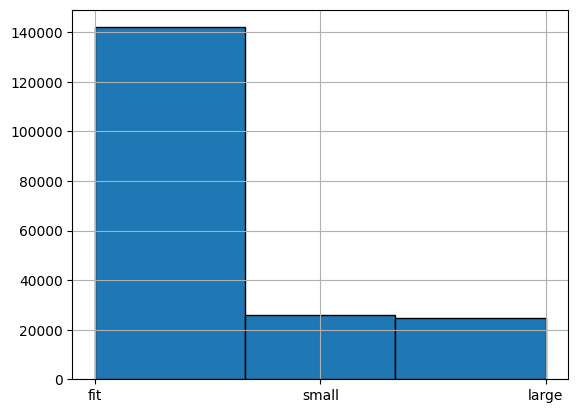

In [ ]:
target_feature = 'fit'
n_classes = df[target_feature].unique().shape[0]
df[target_feature].hist(bins=n_classes, edgecolor='black');

In [ ]:
#checking for null values and dropping them.
def check_nulls(data):
    for col in df:
        print(f'Column \'{col}\'. Is null - {data[col].isnull().sum()}')


to_drop = df[df['fit'] == 'fit'].isnull().any(axis=1)
n = to_drop.sum()
to_drop.shape, df.shape
df = df.drop(df[df['fit'] == 'fit'][to_drop].index, axis=0)
print(f'Dropped {n} examples')

check_nulls(df)

Dropped 34325 examples
Column 'fit'. Is null - 0
Column 'user_id'. Is null - 0
Column 'bust size'. Is null - 4740
Column 'item_id'. Is null - 0
Column 'weight'. Is null - 7658
Column 'rating'. Is null - 19
Column 'rented for'. Is null - 1
Column 'review_text'. Is null - 0
Column 'body type'. Is null - 3734
Column 'review_summary'. Is null - 0
Column 'category'. Is null - 0
Column 'height'. Is null - 191
Column 'size'. Is null - 0
Column 'age'. Is null - 254
Column 'review_date'. Is null - 0


In [ ]:
#converting height from feet to inches
def parse_ht(height):
    ht_ = height.split("' ")
    ft_ = float(ht_[0])
    in_ = float(ht_[1].replace("\"",""))
    return (12*ft_) + in_
#converting weight from pounds to kilos.
def pounds_to_kilos(s):
    return int(s.replace('lbs', '')) * 0.45359237

df['height'] = (df['height']
                        .fillna("0' 0\"")
                        .apply(parse_ht))
df['height'][df['height'] == 0] = df['height'].median()

df['weight'] = (df['weight']
                        .fillna('0lbs')
                        .apply(pounds_to_kilos))
df['weight'][df['weight'] == 0.0] = df['weight'].median()

df['user_id'] = pd.to_numeric(df['user_id'])
df['bust size'] = df['bust size'].fillna(df['bust size'].value_counts().index[0])
df['body type'] = df['body type'].fillna(df['body type'].value_counts().index[0])
df['item_id'] = pd.to_numeric(df['item_id'])
df['size'] = pd.to_numeric(df['size'])

df['age'] = pd.to_numeric(df['age'])
df['age'] = df['age'].fillna(df['age'].median())

df['rating'] = pd.to_numeric(df['rating'])
df['rating'] = df['rating'].fillna(df['rating'].median())

df['review_date'] = pd.to_datetime(df['review_date'], format='%B %d, %Y')
#replacing null values of numeric features with median values.
df.info()

/tmp/ipykernel_723/3042125969.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['height'][df['height'] == 0] = df['height'].median()
/tmp/ipykernel_723/3042125969.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of

<class 'pandas.core.frame.DataFrame'>
Index: 158219 entries, 0 to 192543
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   fit             158219 non-null  object        
 1   user_id         158219 non-null  int64         
 2   bust size       158219 non-null  object        
 3   item_id         158219 non-null  int64         
 4   weight          158219 non-null  float64       
 5   rating          158219 non-null  float64       
 6   rented for      158218 non-null  object        
 7   review_text     158219 non-null  object        
 8   body type       158219 non-null  object        
 9   review_summary  158219 non-null  object        
 10  category        158219 non-null  object        
 11  height          158219 non-null  float64       
 12  size            158219 non-null  int64         
 13  age             158219 non-null  float64       
 14  review_date     158219 non-null  datetime

In [ ]:
#column mapper
col_mapper = {
    'bust size': 'bust_size',
    'weight': 'usr_weight_kg',
    'rating': 'review_rating',
    'rented for': 'rented_for',
    'body type': 'body_type',
    'category': 'product_category',
    'height': 'usr_height_inchs',
    'size': 'product_size',
    'age': 'usr_age',
}
df.rename(col_mapper, axis=1, inplace=True)

In [ ]:
newdf = df.copy()

In [ ]:
#bust size and category mapper
import re

def parse_bust_size(s):
    m = re.match(r'(\d+)([A-Za-z])(\+?)', s)
    if m:
        return pd.Series(data=[int(m.group(1)), m.group(2).lower()])
    return []

mapper = {
    0: 'bust_size_num',
    1: 'bust_size_cat'
}

temp_df = newdf['bust_size'].apply(parse_bust_size).rename(mapper, axis=1)
temp_df['bust_size_num'] = pd.to_numeric(temp_df['bust_size_num'])
newdf = newdf.join(temp_df)
newdf.drop(['bust_size'], axis=1, inplace=True)




In [ ]:
#bust category mapper
mapper = {
    'a': 1,
    'b': 2,
    'c': 3,
    'd': 4,
    'e': 5,
    'f': 6,
    'g': 7,
    'h': 8,
    'i': 9,
    'j': 10,
}
newdf['bust_size_cat'] = newdf['bust_size_cat'].map(mapper)

newdf.head()


,fit,user_id,item_id,usr_weight_kg,review_rating,rented_for,review_text,body_type,review_summary,product_category,usr_height_inchs,product_size,usr_age,review_date,bust_size_num,bust_size_cat
0,fit,420272,2260466,62.142155,10.0,vacation,An adorable romper! Belt and zipper were a lit...,hourglass,So many compliments!,romper,68.0,14,28.0,2016-04-20,34,4
1,fit,273551,153475,59.874193,10.0,other,I rented this dress for a photo shoot. The the...,straight & narrow,I felt so glamourous!!!,gown,66.0,12,36.0,2013-06-18,34,2
3,fit,909926,126335,61.234970,8.0,formal affair,I rented this for my company's black tie award...,pear,Dress arrived on time and in perfect condition.,dress,65.0,8,34.0,2014-02-12,34,3
4,fit,151944,616682,65.770894,10.0,wedding,I have always been petite in my upper body and...,athletic,Was in love with this dress !!!,gown,69.0,12,27.0,2016-09-26,34,2
5,fit,734848,364092,62.595747,8.0,date,Didn't actually wear it. It fit perfectly. The...,athletic,Traditional with a touch a sass,dress,68.0,8,45.0,2016-04-30,32,2


In [ ]:
mapper = {
    'small': -1,
    'fit': 0,
    'large': 1,
}
newdf['fit'] = newdf['fit'].map(mapper)

,fit,usr_weight_kg,usr_height_inchs,product_size,usr_age,bust_size_num,bust_size_cat
fit,1.000000,-0.018683,-0.017217,-0.124194,-0.016582,-0.015816,-0.008531
usr_weight_kg,-0.018683,1.000000,0.377023,0.795841,0.062545,0.611228,0.283625
usr_height_inchs,-0.017217,0.377023,1.000000,0.235386,-0.003338,0.156887,0.013364
product_size,-0.124194,0.795841,0.235386,1.000000,0.161174,0.627775,0.297101
usr_age,-0.016582,0.062545,-0.003338,0.161174,1.000000,0.177865,0.067199
bust_size_num,-0.015816,0.611228,0.156887,0.627775,0.177865,1.000000,0.113405
bust_size_cat,-0.008531,0.283625,0.013364,0.297101,0.067199,0.113405,1.000000


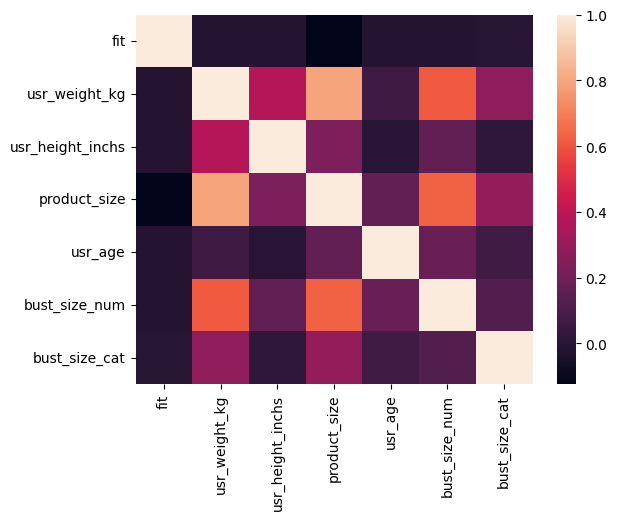

In [ ]:
#Scaling the data and getting correlation matrix.
from sklearn.preprocessing import scale
import seaborn as sns

numeric_dtypes = {'int64', 'float64'}
numeric_features = [c for c in newdf.columns if str(newdf[c].dtype) in numeric_dtypes]
numeric_features.remove('user_id')
numeric_features.remove('item_id')
numeric_features.remove('review_rating')

cleaned_df_scaled = newdf[numeric_features].copy()
cleaned_df_scaled = pd.DataFrame(scale(cleaned_df_scaled), columns=numeric_features)

corr_matrix = cleaned_df_scaled.corr()
sns.heatmap(corr_matrix)
corr_matrix

In [ ]:
print('Pairs of columns that have correlation greater than 0.5: ')
#finding columns which have correlation value greater than 0.5
lim = 0.5
corr_cols = []
for i in range(corr_matrix.shape[0]):
    for j in range(i + 1, corr_matrix.shape[1]):
        if corr_matrix.iloc[i, j] > lim:
            pair = corr_matrix.columns[i], corr_matrix.columns[j]
            corr_cols.append(pair)
            print('({}, {})'.format(*pair))

print('These columns are to be inspected more closely')
corr_cols



Pairs of columns that have correlation greater than 0.5: 
(usr_weight_kg, product_size)
(usr_weight_kg, bust_size_num)
(product_size, bust_size_num)
These columns are to be inspected more closely


[('usr_weight_kg', 'product_size'),
 ('usr_weight_kg', 'bust_size_num'),
 ('product_size', 'bust_size_num')]

/tmp/ipykernel_723/585249381.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')


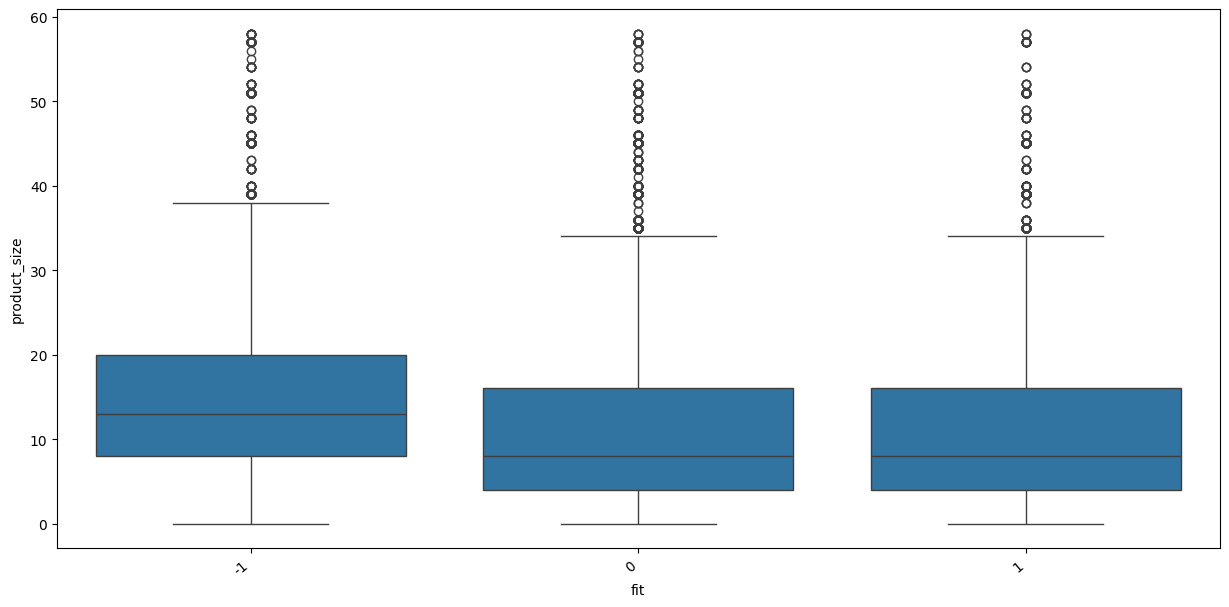

In [ ]:
#plotting box plot between fit and product size.
import matplotlib.pyplot as plt
plt.subplots(figsize=(15,7))
ax=sns.boxplot(x='fit',y='product_size',data=newdf)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')
plt.show()


<Axes: xlabel='body_type', ylabel='Count'>

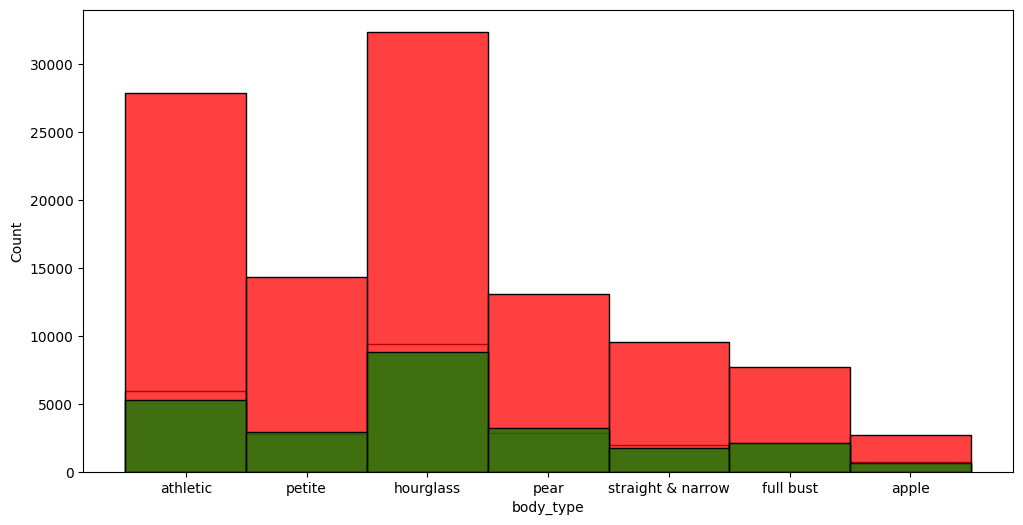

In [ ]:
#Plotting histogram between body type and frequency
plt.figure(figsize=(12,6))
sns.histplot(newdf[newdf['fit'] == -1]['body_type'], color='white')
sns.histplot(newdf[newdf['fit'] == 0]['body_type'],color='red')
sns.histplot(newdf[newdf['fit'] == 1]['body_type'],color='green')

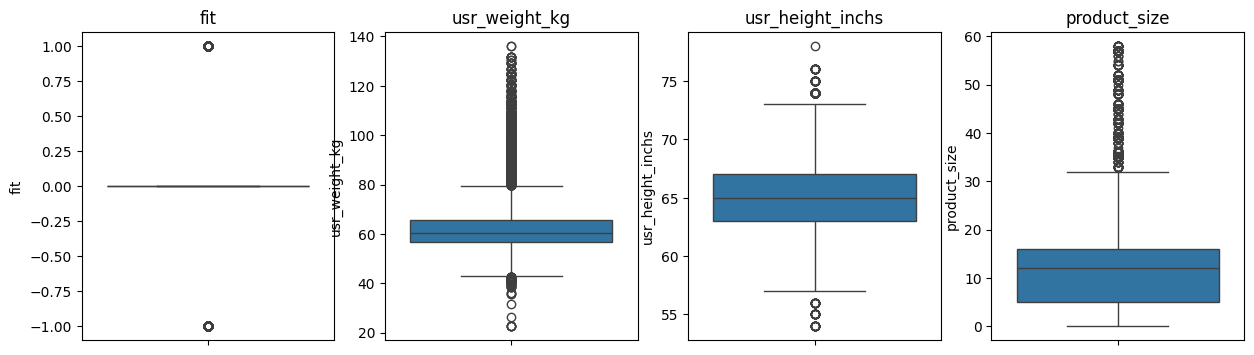

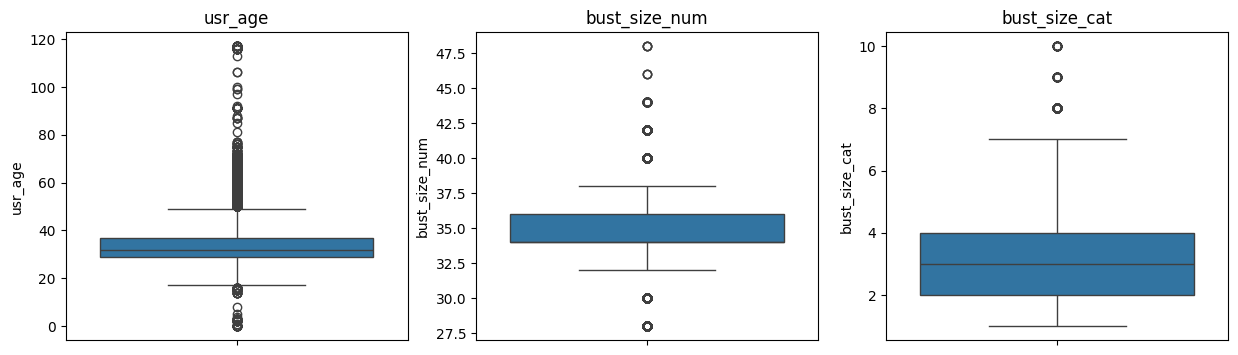

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def draw_boxplots(cols, data, per_line=4):
    n = len(cols)
    per_line = 4
    for i in range(0, n, per_line):
        n_plots = per_line if n - i >= per_line else n % per_line
        fig, axes = plt.subplots(1, n_plots)
        plt.subplots_adjust(wspace=0.2)
        fig.set_figwidth(15)
        fig.set_figheight(4)
        for j in range(n_plots):
            sns.boxplot(data[cols[i + j]], ax=axes[j])
            axes[j].set_title(cols[i + j])  # set the title for the subplot
        plt.show()
draw_boxplots(numeric_features, newdf)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

# Re-identifying numerical features to include only those suitable for the model
numeric_features_for_model = ['usr_weight_kg', 'usr_height_inchs', 'product_size', 'usr_age', 'bust_size_num', 'bust_size_cat', 'review_rating']

X = newdf[numeric_features_for_model]
y = newdf['fit']

# Handle any remaining NaN values in selected features by filling with the median
X = X.fillna(X.median())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train_scaled: (110753, 7)
Shape of X_test_scaled: (47466, 7)
Shape of y_train: (110753,)
Shape of y_test: (47466,)


In [ ]:
# Train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=5000, random_state=42)
log_reg_model.fit(X_train_scaled, y_train)

y_pred = log_reg_model.predict(X_test_scaled)

y_pred_proba = log_reg_model.predict_proba(X_test_scaled)

print("Model training complete. Now evaluating performance...")

Model training complete. Now evaluating performance...


In [ ]:
# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Display the first few prediction probabilities
print("\nFirst 5 prediction probabilities (confidence scores for each class):\n", y_pred_proba[:5])

Accuracy: 0.689672607761345

Classification Report:
               precision    recall  f1-score   support

          -1       0.47      0.11      0.18      7734
           0       0.70      0.98      0.82     32320
           1       0.38      0.02      0.04      7412

    accuracy                           0.69     47466
   macro avg       0.52      0.37      0.35     47466
weighted avg       0.61      0.69      0.59     47466


Confusion Matrix:
 [[  859  6734   141]
 [  486 31730   104]
 [  483  6782   147]]

First 5 prediction probabilities (confidence scores for each class):
 [[0.45563393 0.26132529 0.28304078]
 [0.17035217 0.72352085 0.10612698]
 [0.20855856 0.58745838 0.20398306]
 [0.08321375 0.78108395 0.1357023 ]
 [0.15247624 0.72812568 0.11939808]]
